# Waveform consistency tests: FFT(time domain) vs analytical frequency domain

For every glitch template in `jaxglitches.waveform` we check that the analytical
frequency-domain expression equals the discrete Fourier transform of the
time-domain expression.

**Convention.** The analytical functions return the *continuous* Fourier transform
$H(f)=\int h(t)\,e^{-2\pi i f t}\,dt$. The discrete approximation of that integral is

$$ H(f_k) \;\approx\; \Delta t \sum_n h(t_n)\,e^{-2\pi i f_k t_n} \;=\; \Delta t \cdot \mathrm{rfft}(h)_k . $$

So we compare `dt * rfft(h_time)` against `h_freq`. The DC bin ($f=0$) is skipped
because the analytical expressions carry a $1/f$ factor (zeroed by convention).

For each model and TDI generation we overlay, on a single axes per channel
(X and Y stacked vertically):
- `|fft(time domain)|`  (solid blue)
- `|frequency domain|`  (dashed orange)
- `|fft(time domain) - frequency domain|`  (dotted green) — should sit at the floating-point floor.

In [4]:
import sys
sys.path.insert(0, 'src')

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxglitches import waveform as w

# --- time / frequency grids ---------------------------------------------
dt    = 0.25          # s
T_obs = 3600.0        # s (1 hour)  -> long enough for the glitch to fully decay
N     = int(T_obs / dt)

t  = jnp.arange(N) * dt
f  = jnp.fft.rfftfreq(N, dt)
f_safe = f.at[0].set(1.0)   # avoid 1/0 in analytical formulas; DC bin is ignored below

print(f'N = {N} samples, df = {float(f[1]):.3e} Hz, f_Nyq = {float(f[-1])} Hz')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


N = 14400 samples, df = 2.778e-04 Hz, f_Nyq = 2.0 Hz


In [5]:
# --- shared physical parameters -----------------------------------------
Deltav = 2.22616837e-11   # m/s
T      = w.T_ARM_s       # s, one-way light travel time
t0     = 200.0           # s, glitch onset (well inside the window)

tau    = 5.0             # s, single decay time (1exp)
tau1   = 5.0             # s, decay times (2exp)
tau2   = 7.0

# positional arg packs: (onset, Deltav, decay(s)..., T) -- identical order for
# the time-domain and frequency-domain version of each model.
params = {
    '1exp':     (t0, Deltav, tau,        T),
    '2exp':     (t0, Deltav, tau1, tau2, T),
}

In [6]:
def compare(name, time_fn, freq_fn, p):
    """Overlay |fft(time)|, |freq| and |fft(time) - freq| on one axes per channel.

    The X and Y channels are stacked vertically (not side by side).
    """
    Xt, Yt, _ = time_fn(t, *p)
    Xf, Yf, _ = freq_fn(f_safe, *p)

    fp = f[1:]   # drop DC
    fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
    fig.suptitle(name, fontsize=14, fontweight='bold')

    for row, (ht, hf, ch) in enumerate([(Xt, Xf, 'X'), (Yt, Yf, 'Y')]):
        H = dt * jnp.fft.rfft(ht)
        diff = jnp.abs(H[1:] - hf[1:])
        max_abs = float(jnp.max(diff))
        max_sig = float(jnp.max(jnp.abs(hf[1:])))
        print(f'{name:22s} {ch}:  max|fft - freq| = {max_abs:.2e}   '
              f'(signal max = {max_sig:.2e},  rel = {max_abs/max_sig:.1e})')

        ax = axes[row]
        ax.loglog(fp, jnp.abs(H[1:]), color='tab:blue',   ls='-',
                  lw=2.0, label='|fft(time domain)|')
        ax.loglog(fp, jnp.abs(hf[1:]), color='tab:orange', ls='--',
                  lw=1.5, label='|frequency domain|')
        ax.loglog(fp, diff, color='tab:green',  ls=':',
                  lw=1.5, label='|fft(time) - freq|')
        ax.set_title(f'{ch} channel')
        ax.set_ylabel('amplitude')
        ax.legend(loc='best')
        ax.grid(True, which='both', alpha=0.2)
    axes[-1].set_xlabel('f [Hz]')
    plt.tight_layout()
    plt.show()

## TDI 1

TDI 1 - 1 exponential  X:  max|fft - freq| = 2.82e-24   (signal max = 2.48e-18,  rel = 1.1e-06)
TDI 1 - 1 exponential  Y:  max|fft - freq| = 5.91e-24   (signal max = 2.48e-18,  rel = 2.4e-06)


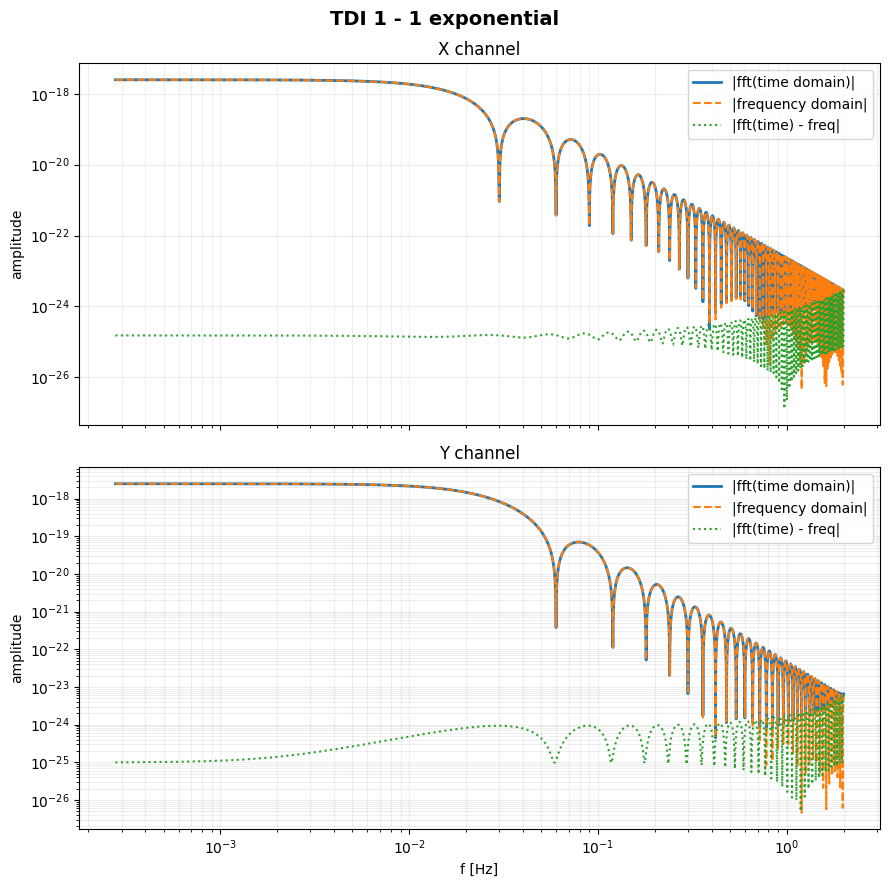

In [7]:
compare('TDI 1 - 1 exponential', w.tdi1_1exp_glitch, w.tdi1_1exp_f_glitch, params['1exp'])

TDI 1 - 2 exponentials X:  max|fft - freq| = 2.01e-24   (signal max = 2.48e-18,  rel = 8.1e-07)
TDI 1 - 2 exponentials Y:  max|fft - freq| = 4.22e-24   (signal max = 2.48e-18,  rel = 1.7e-06)


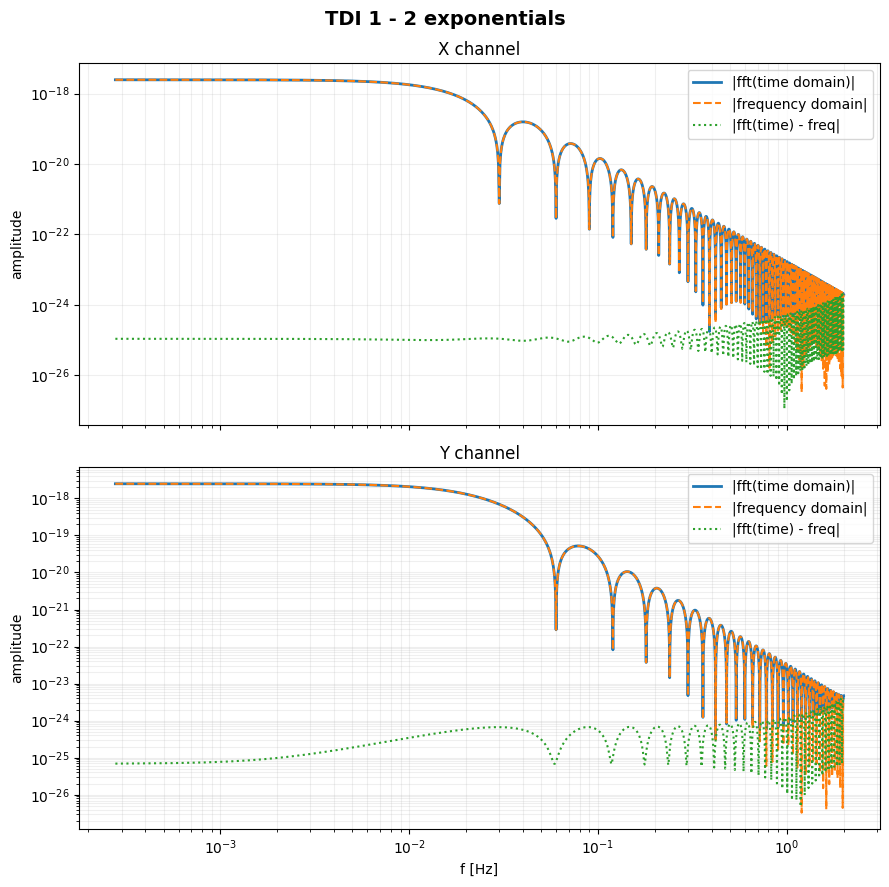

In [8]:
compare('TDI 1 - 2 exponentials', w.tdi1_2exp_glitch, w.tdi1_2exp_f_glitch, params['2exp'])

## TDI 2

TDI 2 - 1 exponential  X:  max|fft - freq| = 5.69e-24   (signal max = 3.23e-18,  rel = 1.8e-06)
TDI 2 - 1 exponential  Y:  max|fft - freq| = 8.60e-24   (signal max = 3.86e-18,  rel = 2.2e-06)


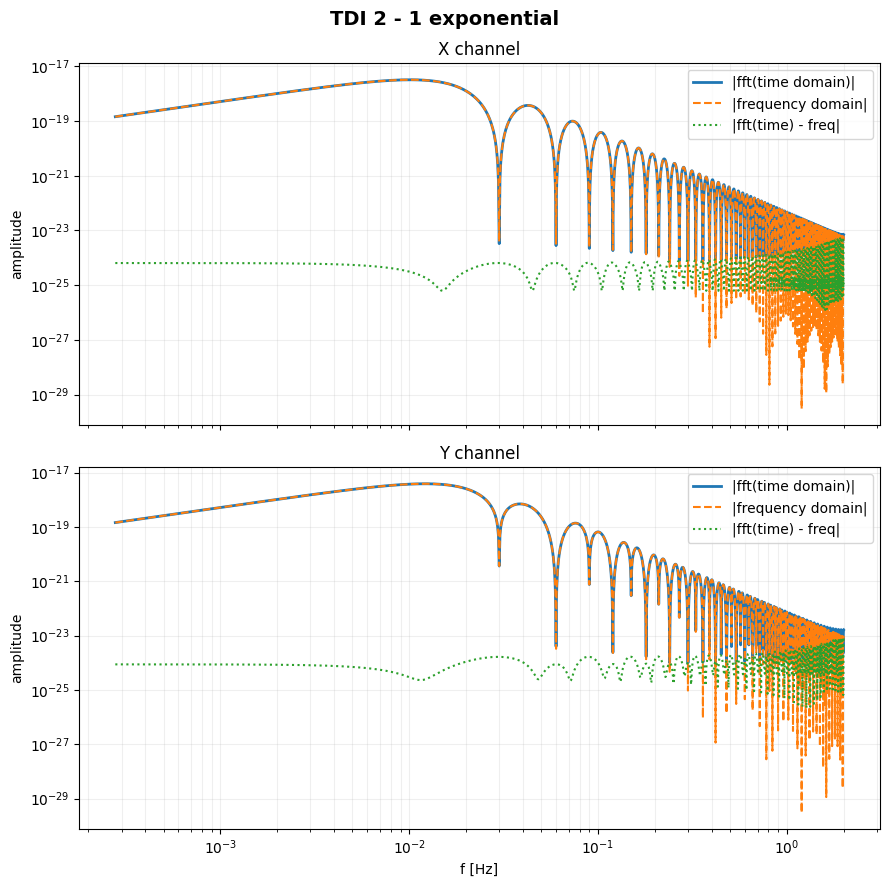

In [9]:
compare('TDI 2 - 1 exponential', w.tdi2_1exp_glitch, w.tdi2_1exp_f_glitch, params['1exp'])

TDI 2 - 2 exponentials X:  max|fft - freq| = 4.07e-24   (signal max = 3.10e-18,  rel = 1.3e-06)
TDI 2 - 2 exponentials Y:  max|fft - freq| = 6.14e-24   (signal max = 3.65e-18,  rel = 1.7e-06)


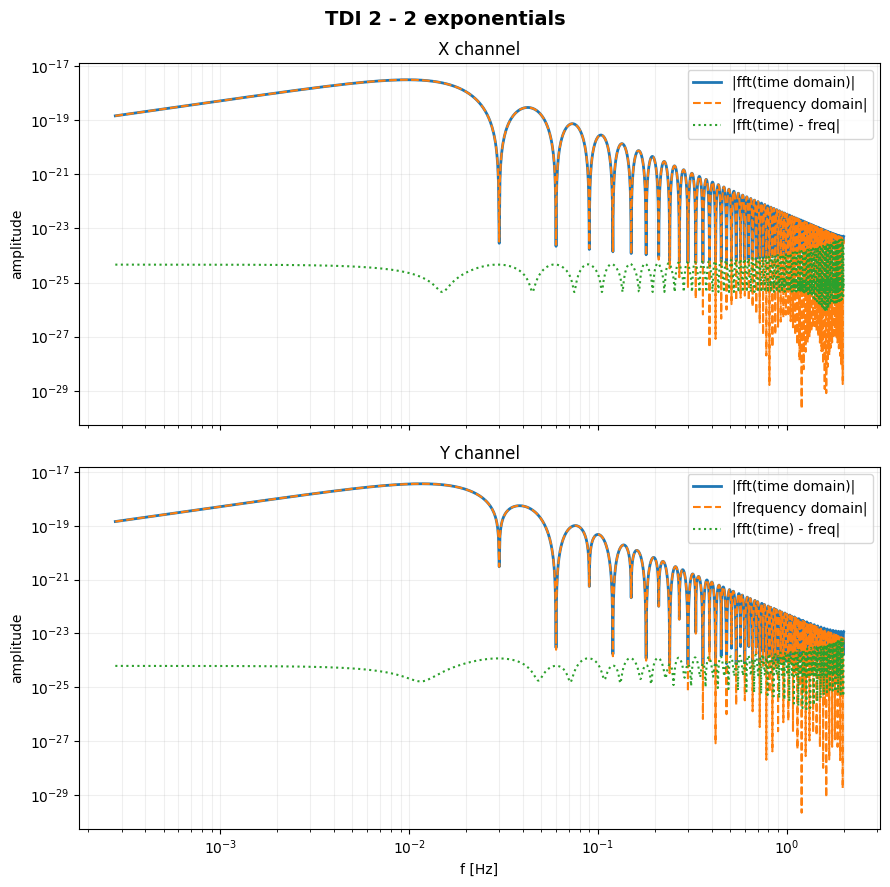

In [10]:
compare('TDI 2 - 2 exponentials', w.tdi2_2exp_glitch, w.tdi2_2exp_f_glitch, params['2exp'])

## TDI 1 vs TDI 2 for the 2-exponential model

All four pairings now agree to ~1e-24 (machine precision).

This previously failed for **TDI 1 - 2 exponentials**: the time-domain
`tdi1_2exp_glitch` had been copied with the **TDI-2** delay structure
(X delays `{t0, t0+4T, t0+8T}`, coefficients `{+1, -2, +1}`), making it identical
to `tdi2_2exp_glitch` and inconsistent with the first-gen frequency formula.

It has been fixed to the **first-generation** structure (X delays `{t0, t0+4T}`
→ transfer factor `(-1 + e^{-4i\\,T\\omega})`; Y delays `{t0+T, t0+3T}`), matching
`tdi1_1exp_glitch`. The cell below confirms the two generations are now distinct.

In [11]:
# TDI-1 and TDI-2 2exp time-domain waveforms are now genuinely different:
a = w.tdi1_2exp_glitch(t, *params['2exp'])
b = w.tdi2_2exp_glitch(t, *params['2exp'])
print('max |tdi1_2exp_glitch - tdi2_2exp_glitch|  (X) =',
      float(jnp.max(jnp.abs(a[0] - b[0]))), ' (was ~0 before the fix)')
print('max |tdi1_2exp_glitch - tdi2_2exp_glitch|  (Y) =',
      float(jnp.max(jnp.abs(a[1] - b[1]))))

max |tdi1_2exp_glitch - tdi2_2exp_glitch|  (X) = 1.445670735844087e-19  (was ~0 before the fix)
max |tdi1_2exp_glitch - tdi2_2exp_glitch|  (Y) = 2.316797200163035e-19
